In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import zarr
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [4]:
root = Path('/Volumes/data/Sasaki/MTsingleBeads')
#root = Path('/mnt/SSD/Sasaki/MTsingleBeads')

beads1um = "beads1um"
beads3um = "beads3um"
beads7um = "beads7um"


def func(root, folder):

    particles = []
    bgs = []

    for input_dir in glob.glob(str(root / folder / "*"/ "*")):
        input_dir = Path(input_dir)
        particle= xr.open_zarr(input_dir / "local_polar_w.zarr")
        bg = xr.open_zarr(input_dir / "local_polar_bg.zarr")
        p_mean = particle.polar_order.mean(dim=['frame', 'particle'])
        bg_mean = bg.polar_order.mean(dim=['frame', 'particle'])

        particles.append(p_mean)
        bgs.append(bg_mean)

    return particles, bgs

particles1um, bgs1um = func(root, beads1um)

FileNotFoundError: /Volumes/data/Sasaki/MTsingleBeads/beads1um/20260122/exp001/local_polar_w.zarr does not exist

'\nfig.savefig(fig_png)\nfig.savefig(fig_pdf)\n'

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

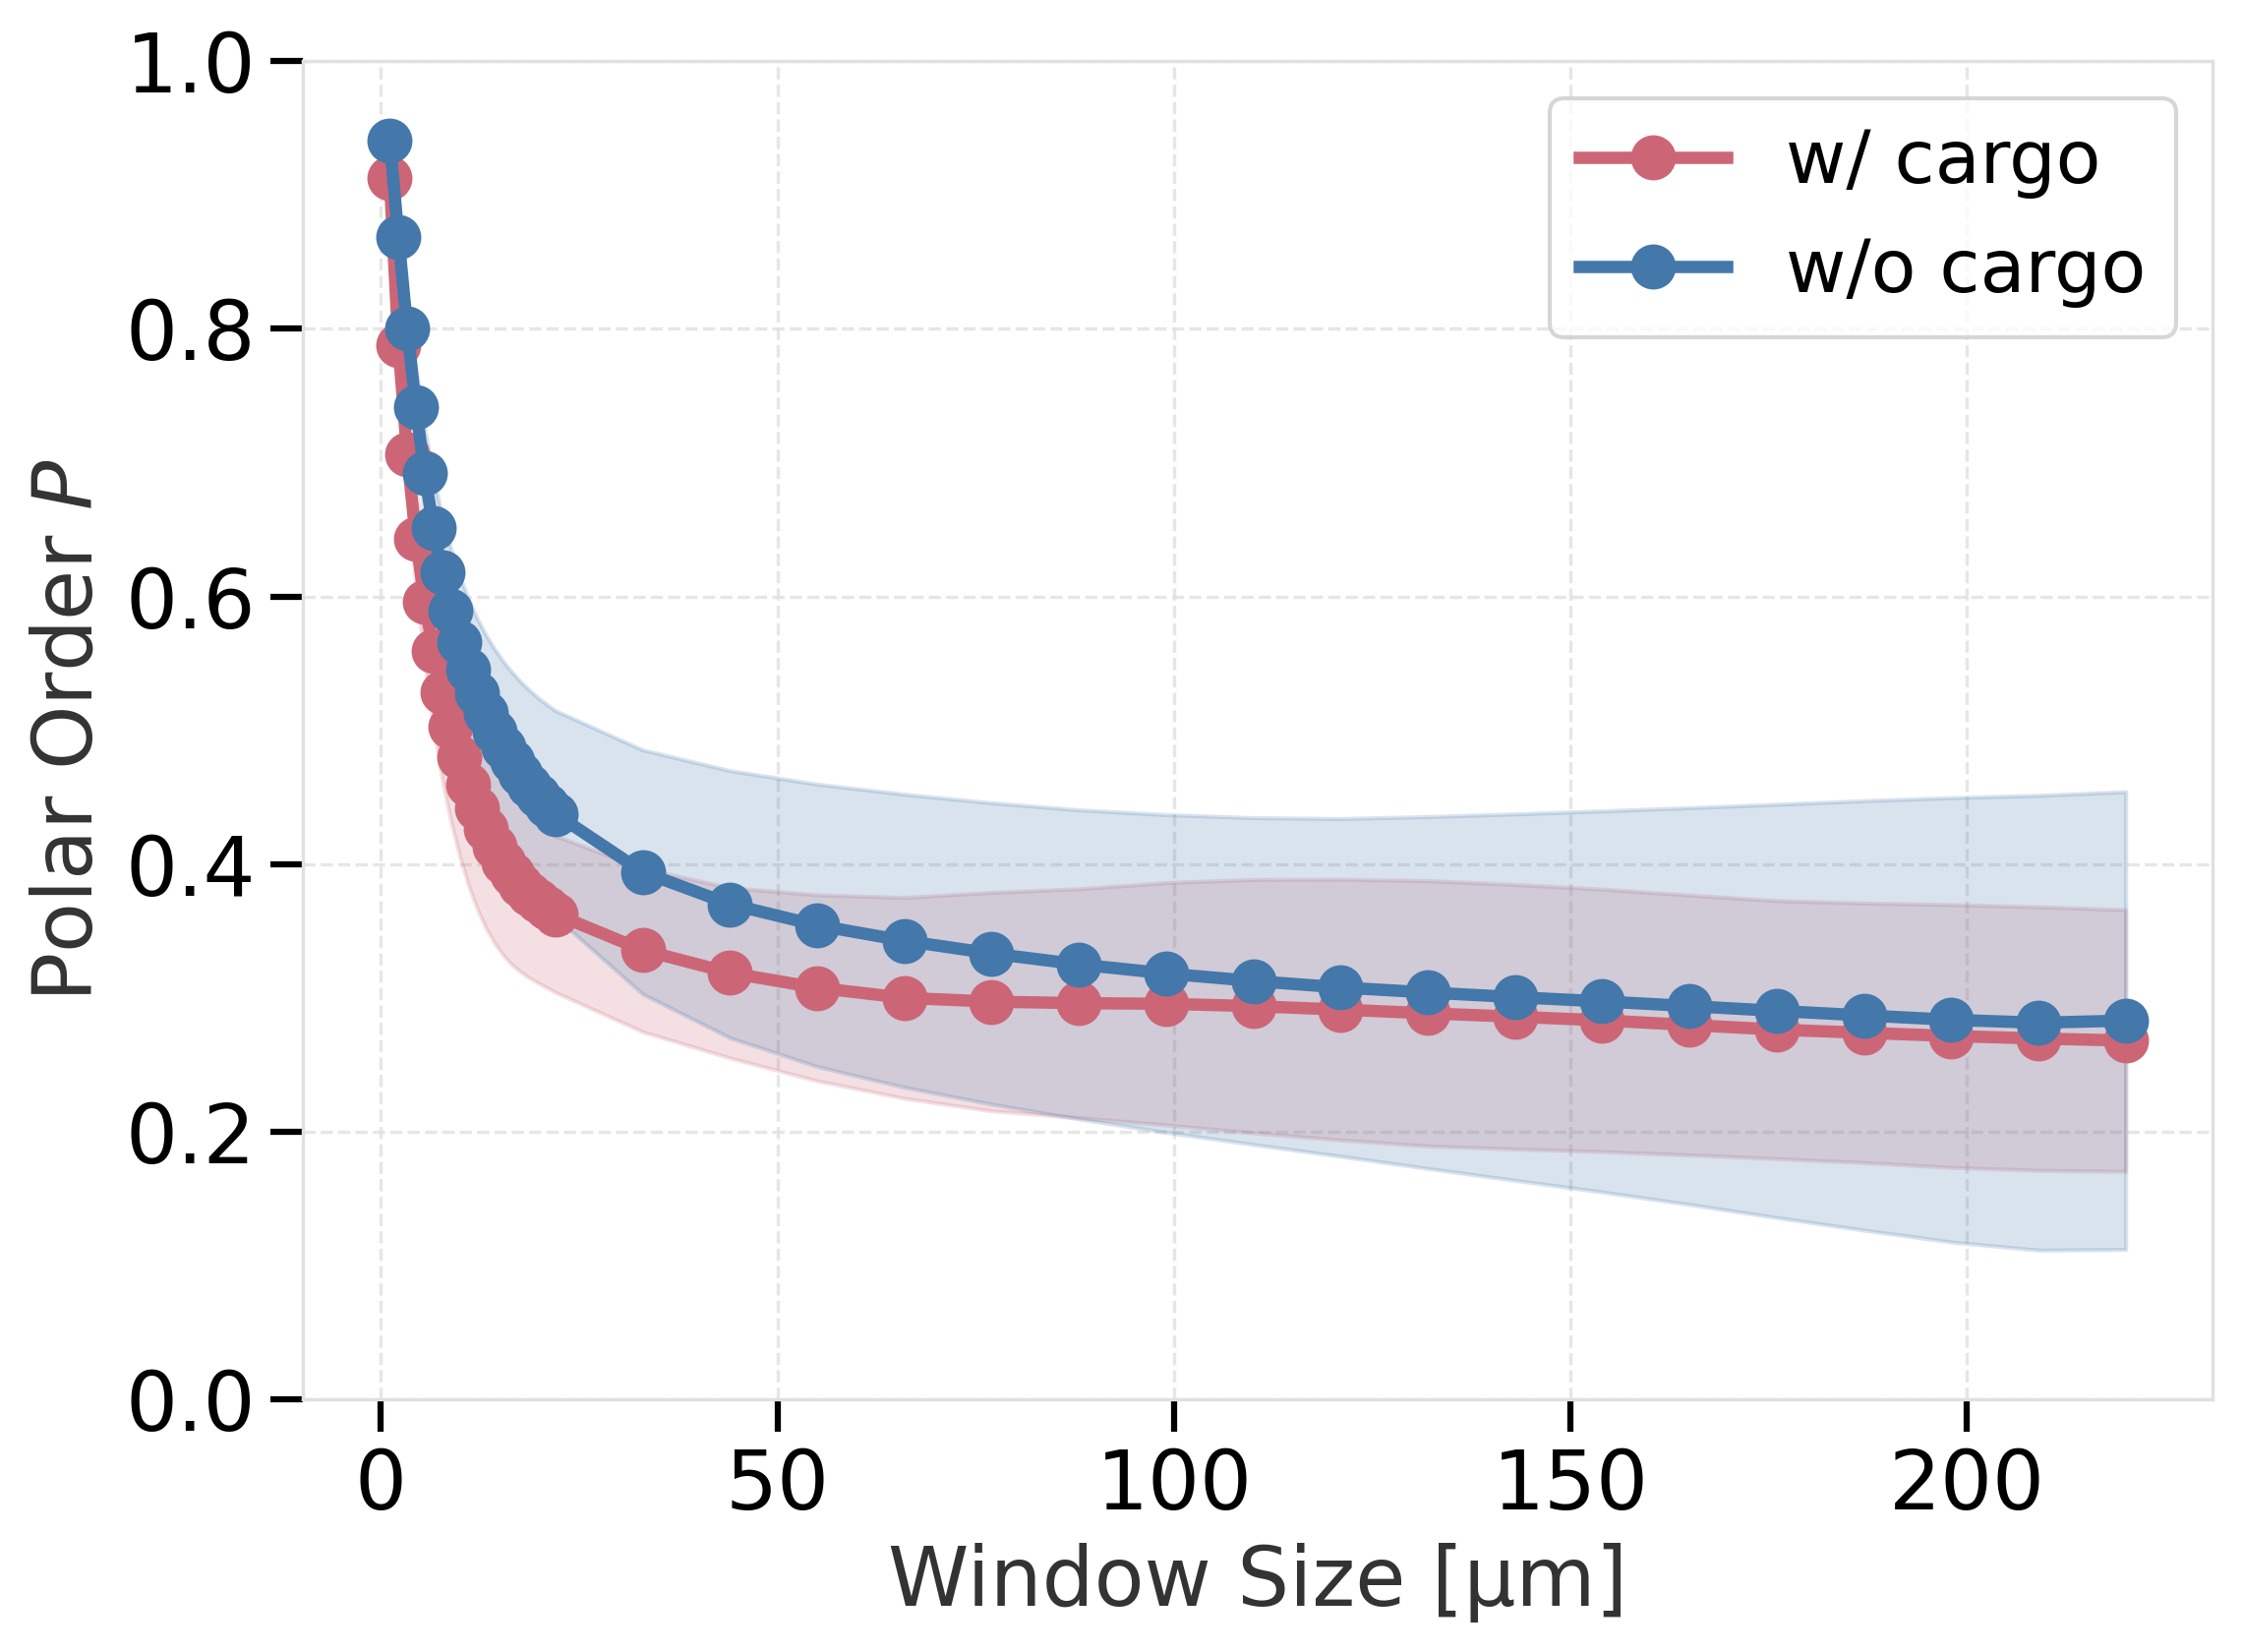

In [3]:
import matplotlib.pyplot as plt
import numpy as np

scale = 0.11

fig, ax = plt.subplots()

# --- 1. 統計量の計算 (w/ cargo) ---
# 粒子ごと、フレームごとの平均をとる前の「ばらつき」を保持

p_means = []
bg_means = []

for particle in particles:
    mean = particle.polar_order.mean(dim=['frame', 'particle'])
    p_means.append(mean)
    #p_std  = particle.polar_order.std(dim=['frame', 'particle']) # 標準偏差

p_array = np.array(p_means)
p_mean = np.mean(p_array, axis=0)
p_std = np.std(p_array, axis=0)

# --- 2. 統計量の計算 (w/o cargo) ---
for bg in bgs:
    mean = bg.polar_order.mean(dim=['frame'])
    bg_means.append(mean)
    #bg_std  = bg.polar_order.std(dim=['frame'])

bg_array = np.array(bg_means)
bg_mean = np.mean(bg_array, axis=0)
bg_std = np.std(bg_array, axis=0)

# --- 3. プロット ---

# ウィンドウサイズ（x軸）の取得
x_coords = mean['window size'].values * scale

# w/ cargo
ax.plot(x_coords, p_mean, color='#CC6677', marker='o', label='w/ cargo')
ax.fill_between(x_coords, p_mean - p_std, p_mean + p_std, color='#CC6677', alpha=0.2)

# w/o cargo
ax.plot(x_coords, bg_mean, color='#4477AA', marker='o', label='w/o cargo')
ax.fill_between(x_coords, bg_mean - bg_std, bg_mean + bg_std, color='#4477AA', alpha=0.2)



ax.legend()
ax.set_xlabel("Window Size [\u03bcm]")
ax.set_ylabel("Polar Order $P$")
ax.set_ylim(0, 1)

fig_dir = Path("/Users/sasakinozomu/code/MTCargo_analysis/notebooks/figures")

fig_png = fig_dir / "local_polar.png"
fig_pdf = fig_dir / "local_polar.pdf"
"""
fig.savefig(fig_png)
fig.savefig(fig_pdf)
"""